# K_08 – Alternative Speicher

**Grid-Arbitrage** · Batteriespeicher-Arbitrage im Schweizer Strommarkt (Kür)

**Gruppe:** SC26_Gruppe_2 | **Verantwortlich:** Patrik Neunteufel | **Datum:** März 2026

---

*Positionierung alternativer Speichertechnologien im CH-Marktkontext.*


| [← K_07 – Technologievergleich](K_07_Technologievergleich.ipynb) | [↑ Übersicht ↑](../organisation/O_01_Project_Overview.ipynb) | [K_09 – Eigenverbrauchsoptimierung →](K_09_Eigenverbrauch.ipynb) |
|:---|:---:|---:|

## Inhaltsverzeichnis<a id='toc_K_08'></a>

[Einleitung](#einleitung_K_08)  
[Initialisierung](#initialisierung_K_08)  
1 [Steckbriefe](#steckbriefe_K_08)  
2 [Positionierung: Entladezeit vs. Wirkungsgrad](#positionierung-entladezeit-vs-wirkungsgrad_K_08)  
3 [Einordnung im CH-Kontext](#einordnung-im-ch-kontext_K_08)  
[Fazit](#fazit_K_08)  
[Abschluss](#abschluss_K_08)  


---
## Einleitung <a id='einleitung_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

Batterien dominieren den Kleinst- und Mittelsegmentmarkt (< 10 MWh).
Für grosse Energiemengen (> 100 MWh) und lange Entladezeiten (> 8 h) sind
mechanische und chemische Speicher oft günstiger und dauerhafter.

In der Schweiz ist **Pumpspeicher** bereits etabliert — er ist mit Abstand
der grösste Energiespeicher des Landes und unverzichtbar für die Stabilität
des europäischen Verbundnetzes.


## Initialisierung<a id='initialisierung_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

Bibliotheken laden, `../sync/config.json` lesen, Verzeichnispfade setzen.

**Imports und Versionen:**

In [1]:
# ── lib/ aus Projekt-Root erreichbar machen + lib-Imports ───────────────────
import sys, os
def _find_project_root():
    cur = os.path.abspath('.')
    for _ in range(5):
        if os.path.isfile(os.path.join(cur, 'sync', 'config.json')):
            return cur
        cur = os.path.dirname(cur)
    return os.path.abspath('..')

_PROJECT_ROOT = _find_project_root()
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except Exception:
    pass

from lib.io_ops    import load_transfer, final_check
from lib.plotting  import show_source

print(f'lib-Pfad aktiv: {_PROJECT_ROOT}/lib')


lib-Pfad aktiv: C:\Users\patri\Documents\docker\python\OWN\Grid-Arbitrage/lib


In [2]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore')
from datetime import datetime

# Versionen anzeigen für Reproduzierbarkeit
print(f"Numpy        Version: {np.__version__}")
print(f"📅 Zuletzt ausgeführt am: {datetime.now().strftime('%d.%m.%Y um %H:%M:%S')}")

Numpy        Version: 2.2.6
📅 Zuletzt ausgeführt am: 26.04.2026 um 21:36:50


**Setup – Konfiguration & Verzeichnisstruktur:** Lädt `../sync/config.json` (SSOT), setzt Pfade.

In [3]:
with open('../sync/config.json') as f:
    CFG = json.load(f)

SZ_AKTIV   = CFG['szenarien']['gleichzeitigkeit_aktiv']
FORCE_RELOAD = CFG.get('force_reload', {})  # konventionskonform gelesen
CHARTS_DIR = os.path.join('../output', 'charts', SZ_AKTIV)
os.makedirs(CHARTS_DIR, exist_ok=True)
DPI = CFG['visualisierung']['output_dpi']  # SSOT: ../sync/config.json
# ── Farben & Stil aus ../sync/config.json (SSOT) ─────────────────────────────────────
# Bestehende Variablen (Rückwärtskompatibilität)
_viz        = CFG.get('visualisierung', {}).get('farben', {})
BG_DARK     = _viz.get('bg_dark',    '#0d1117')
BG_PANEL    = _viz.get('bg_panel',   '#141414')
C_PRICE     = _viz.get('c_price',    '#FFA726')
C_LOAD      = _viz.get('c_load',     '#66BB6A')
C_CHARGE    = _viz.get('c_charge',   '#1565C0')
C_FEED      = _viz.get('c_feed',     '#B71C1C')
SEG_COLORS  = _viz.get('seg_colors', ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350'])
C_PRIV, C_GEW, C_IND, C_UTIL = SEG_COLORS

# UI-Strukturfarben
C_ACHSE      = _viz.get('c_achse',      '#aaaaaa')  # Achsenbeschriftungen
C_TICK       = _viz.get('c_tick',       '#bbbbbb')  # Tick-Labels
C_SPINE      = _viz.get('c_spine',      '#333333')  # Achsenrahmen
C_LEGENDE_BG = _viz.get('c_legende_bg', '#111111')  # Legenden-Hintergrund
C_GITTER     = _viz.get('c_gitter',     '#cccccc')  # Gitterlinien

# Funktionale Extrafarben (nur laden was das NB braucht)
C_DISPATCH   = _viz.get('c_dispatch',   '#AB47BC')  # Dispatch-optimal
C_STACKING   = _viz.get('c_stacking',   '#5DCAA5')  # Revenue Stacking
C_SOLAR      = _viz.get('c_solar',      '#FDD835')  # Solar-Ertrag
C_GRENZWERT  = _viz.get('c_amber_dark', '#FF6F00')  # Grenzwert / Warnung
C_CYAN       = _viz.get('c_cyan',       '#26C6DA')  # Flusswasser / Alt. Speicher
C_GRUEN_DARK = _viz.get('c_gruen_dark', '#388E3C')  # Erneuerbare

# Stilkonstanten
_stil               = CFG.get('visualisierung', {}).get('stil', {})
LW                  = _stil.get('linienbreite_standard', 1.5)   # Standard-Linienbreite
LW_DUENN            = _stil.get('linienbreite_duenn',    0.8)   # dünne Linien
LW_DICK             = _stil.get('linienbreite_dick',     2.5)   # dicke Linien
ALPHA_FLAECHE       = _stil.get('alpha_flaeche',         0.12)  # dezente Füllung
ALPHA_FLAECHE_STARK = _stil.get('alpha_flaeche_stark',   0.35)  # Balken / Füllung
ALPHA_LEGENDE       = _stil.get('alpha_legende',         0.30)  # Legenden-BG
ALPHA_GEDAEMPFT     = _stil.get('alpha_linie_gedaempft', 0.55)  # Nebenlinien
FS_TITEL            = _stil.get('schriftgroesse_titel',   13)   # Chart-Titel
FS_ACHSE            = _stil.get('schriftgroesse_achse',   10)   # Achsenbeschr.
FS_TICK             = _stil.get('schriftgroesse_tick',     9)   # Ticks
FS_LEGENDE          = _stil.get('schriftgroesse_legende',  8)   # Legende
FS_KLEIN            = _stil.get('schriftgroesse_klein',    7)   # Annotationen

# matplotlib rcParams — nur stabile, versionsunabhängige Keys (matplotlib >= 3.5)
# axes.titlecolor (3.8+) und axes.grid (stört Karten) bewusst NICHT gesetzt
import matplotlib as mpl
mpl.rcParams.update({
    'figure.facecolor':  BG_DARK,
    'axes.facecolor':    BG_PANEL,
    'axes.edgecolor':    C_SPINE,
    'axes.labelcolor':   C_ACHSE,
    'axes.labelsize':    FS_ACHSE,
    'axes.titlesize':    FS_TITEL,
    'xtick.color':       C_TICK,
    'ytick.color':       C_TICK,
    'xtick.labelsize':   FS_TICK,
    'ytick.labelsize':   FS_TICK,
    'text.color':        'white',
    'lines.linewidth':   LW,
    'legend.facecolor':  C_LEGENDE_BG,
    'legend.framealpha': ALPHA_LEGENDE,
    'legend.fontsize':   FS_LEGENDE,
    'legend.edgecolor':  C_SPINE,
})
print('Farben & Stil geladen.')

print(f"Setup OK | Charts → {CHARTS_DIR}")

Farben & Stil geladen.
Setup OK | Charts → ../output\charts\realistisch


**⚙ Markdown-Prüfwerte (config-abhängig) und 📊 Markdown-Prüfwerte (transfer-abhängig)**:  
Werte mit ⚙ kommen aus `../sync/config.json`, Werte mit 📊 aus `../sync/transfer.json` (NB03-Output).  
Bei jeder Änderung dieser Quellen → Output mit ⚙/📊-Stellen im Markdown abgleichen.


In [4]:
# ── ⚙ Markdown-Prüfwerte (config-abhängig) ─────────────────────────────────
print('=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===')
_pflicht = CFG['pflicht']['simulation']
print(f'  Round-Trip-Effizienz LFP   = {_pflicht["efficiency_roundtrip"]*100:.0f} %  (Modellannahme NB02)')
print(f'  (K_08 vergleicht 6 Speicher-Technologien literaturbasiert —')
print(f'   keine direkten config-Werte ausser dem RTE-Vergleichswert.)')


=== ⚙ MARKDOWN-PRÜFWERTE (config-abhängig) ===
  Round-Trip-Effizienz LFP   = 92 %  (Modellannahme NB02)
  (K_08 vergleicht 6 Speicher-Technologien literaturbasiert —
   keine direkten config-Werte ausser dem RTE-Vergleichswert.)


**🔎 Quellcode der importierten lib-Funktion**

`load_transfer` aus `lib.io_ops` — liest `../sync/transfer.json`.


In [5]:
show_source(load_transfer)


<details>
<summary>🔎 Quellcode: <code>load_transfer</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def load_transfer(path='../sync/transfer.json', key=None, default=None):
    """Lädt transfer.json und gibt das ganze Dict oder einen Teil zurück.

    Verhalten
    ---------
    * Datei existiert nicht oder ist leer → Rückgabe ist ``default`` (bei
      key=None: ``default`` oder ``{}``). Gibt Warnung auf stdout aus.
    * Datei existiert → gibt bei ``key=None`` das ganze Dict zurück, bei
      gegebenem ``key`` nur den entsprechenden Teilbaum (``default``, wenn
      Key fehlt).

    Parameter
    ---------
    path : str, default '../sync/transfer.json'
        Pfad zur transfer.json.
    key : str, optional
        Top-Level-Key ('datenzeitraum', 'simulation', ...). Bei None wird
        das komplette Dict zurückgegeben.
    default : any, optional
        Rückgabewert bei fehlender Datei oder fehlendem Key. Bei key=None
        ist der Default ``{}``.

    Return
    ------
    dict oder der Wert des angefragten Keys.
    """
    import json as _json

    if default is None and key is None:
        default = {}

    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f'⚠️  {path} nicht gefunden oder leer — NB01/NB02 zuerst ausführen')
        return default

    with open(path, encoding='utf-8') as _f:
        data = _json.load(_f)

    if key is None:
        return data
    return data.get(key, default)
```

</details>


In [6]:
# ── 📊 Markdown-Prüfwerte (transfer-abhängig) ──────────────────────────────
TF      = load_transfer()
_tf_dz  = TF.get('datenzeitraum', {})
print('=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===')
print(f'  Datenzeitraum         = {_tf_dz.get("start_date","?")} bis {_tf_dz.get("end_date","?")}')
print(f'  (K_08 ist rein literaturbasiert — keine direkten transfer-Werte.)')


=== 📊 MARKDOWN-PRÜFWERTE (transfer-abhängig) ===
  Datenzeitraum         = 2023 bis 2026
  (K_08 ist rein literaturbasiert — keine direkten transfer-Werte.)


---
## 1. Steckbriefe <a id='steckbriefe_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

### 3.1 Pumpspeicher (Pumped Hydro Storage — PHS)

| Kennwert | Wert |
|---|---|
| **Typische Kapazität** | 100 MWh … 10 GWh |
| **System-CAPEX** | 5–15 EUR/kWh (bei grosser Kapazität) |
| **Lebensdauer** | 50–100 Jahre |
| **Round-Trip-Wirkungsgrad** | 70–85 % |
| **Selbstentladung** | praktisch 0 |
| **Reaktionszeit** | < 30 s (Spin-Mode, Turbine läuft) · 1–3 Min (Cold-Start aus Stillstand) · 5–15 Min (Mode-Switch Pump↔Generate) |
| **CH-Relevanz** | ★★★★★ — wichtigster CH-Speicher |

Überschussstrom pumpt Wasser in ein Oberbecken. Bei Bedarf fliesst es durch
Turbinen zurück. Die Schweiz betreibt ~9.5 GW installierte Pumpspeicherleistung
(weltweit Spitzenposition pro Kopf).

*CH-Beispiele: Nant de Drance (900 MW, VS) · Linth-Limmern (1 GW, GL) · Grimsel KWO (700 MW, BE)*

**Grenzen:** Geographisch gebunden (Topographie), lange Planungs-/Bauzeit,
politische Hürden. Keine dezentrale Verteilung möglich.

---

### 3.2 Druckluftspeicher (CAES — Compressed Air Energy Storage)

| Kennwert | Wert |
|---|---|
| **Typische Kapazität** | 100 MWh … 5 GWh |
| **System-CAPEX** | 50–100 EUR/kWh |
| **Lebensdauer** | 30–40 Jahre |
| **Round-Trip-Wirkungsgrad** | 40–70 % (A-[CAES](../organisation/O_02_Glossar.ipynb#g-caes): bis 70 %) |
| **Reaktionszeit** | Minuten |
| **CH-Relevanz** | ★★ — Geologie ungeeignet für klassisches CAES |

Überschussstrom komprimiert Luft in Kavernen oder Druckbehälter; zur
Stromerzeugung expandiert sie durch Turbinen.

- **A-CAES (adiabat):** Kompressionswärme wird gespeichert und zurückgeführt → [RTE](../organisation/O_02_Glossar.ipynb#g-rte) bis 70 %, kein Gas nötig
- **D-CAES (diabat):** Benötigt Gas zur Nacherhitzung → RTE ~55 %

**Grenzen in CH:** Keine natürlichen Salzkavernen (wie in D/US); Felskavernen teuer.
Eher für Norddeutschland/Nordsee-Raum relevant.

---

### 3.3 Power-to-X (P2X)

| Kennwert | Wert |
|---|---|
| **Varianten** | Power-to-H₂, Power-to-CH₄, Power-to-Heat, Power-to-Liquid |
| **CAPEX Elektrolyseur** | 500–1 000 EUR/kW_el |
| **Wirkungsgrad Elektrolyse** | 60–80 % |
| **Gesamt-RTE (Strom→Strom)** | 25–45 % |
| **Speicherdauer** | Tage … saisonal |
| **CH-Relevanz** | ★★★ — Pilotprojekte aktiv, saisonal interessant |

Überschussstrom (z.B. Sommer-Solar) wird zu H₂ oder synthetischem Methan
und im Gasnetz gespeichert. Für saisonalen Ausgleich (Solar-Sommer → Winter-Heizung)
strategisch interessant; für tägliche Arbitrage wegen sehr niedrigem RTE ungeeignet.

*CH-Projekte: Hybridwerk Aarmatt (Repower, BE) · H2 Volketswil (ZH) · HyFly (Region Zürich-Flughafen)*

---

### 3.4 Schwungradspeicher (Flywheel Energy Storage — FES)

| Kennwert | Wert |
|---|---|
| **Kapazität Einzeleinheit** | 25–125 kWh (moderne Komposit-Rotoren) |
| **Kapazität Array/Farm** | 1–80 MWh (modular kombiniert) |
| **CAPEX** | 1 000–5 000 EUR/kWh (Einzeleinheit) |
| **Lebensdauer** | > 20 Jahre, > 1 000 000 Zyklen |
| **Round-Trip-Wirkungsgrad** | 90–95 % (Magnetlagerung, Vakuum) |
| **Selbstentladung** | 2–20 %/h (stark systemabhängig) |
| **CH-Relevanz** | ★★ — Grid-[FCR](../organisation/O_02_Glossar.ipynb#g-fcr), USV, Militär-Mikronetze |

Einzeleinheiten haben hohe Selbstentladung (≥5 %/h mit mechanischen Lagern, <1 %/Tag
bei Supraleitungs-Magnetlagerung) — tägliche Arbitrage unwirtschaftlich.
Stärken: Millisekunden-Reaktionszeit, praktisch unbegrenzte Zyklenanzahl, temperaturunabhängig.

**Grossskalige Anlagen (Beispiele):**
- Beacon Power, Stephentown NY: 20 MW / 5 MWh (200 Einheiten, Frequenzregelung)
- Amber Kinetics / PG&E, Fresno CA: 20 MW / 80 MWh (4h Entladezeit)
- China: 30 MW Gridanlage, in Betrieb seit 2024

**Militärische Anwendungen:**
Schwungräder eignen sich für Puls-Energiespeicherung bei Hochenergie-Systemen
(z.B. elektromagnetische Startanlagen EMALS auf Flugzeugträgern, Railgun-Energieversorgung).
Vorteile: keine [Degradation](../organisation/O_02_Glossar.ipynb#g-degradation), keine Temperaturempfindlichkeit, kein Brandrisiko —
wichtig in geschlossenen militärischen Plattformen (Schiffe, U-Boote, Fahrzeuge).


---
## 2. Positionierung: Entladezeit vs. Wirkungsgrad <a id='positionierung-entladezeit-vs-wirkungsgrad_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

Bubble-Chart: X = Entladezeit [h], Y = Wirkungsgrad [%], Grösse = [CAPEX](../organisation/O_02_Glossar.ipynb#g-capex) —
zeigt das technologische Trade-off zwischen Energiedichte und Kosten.


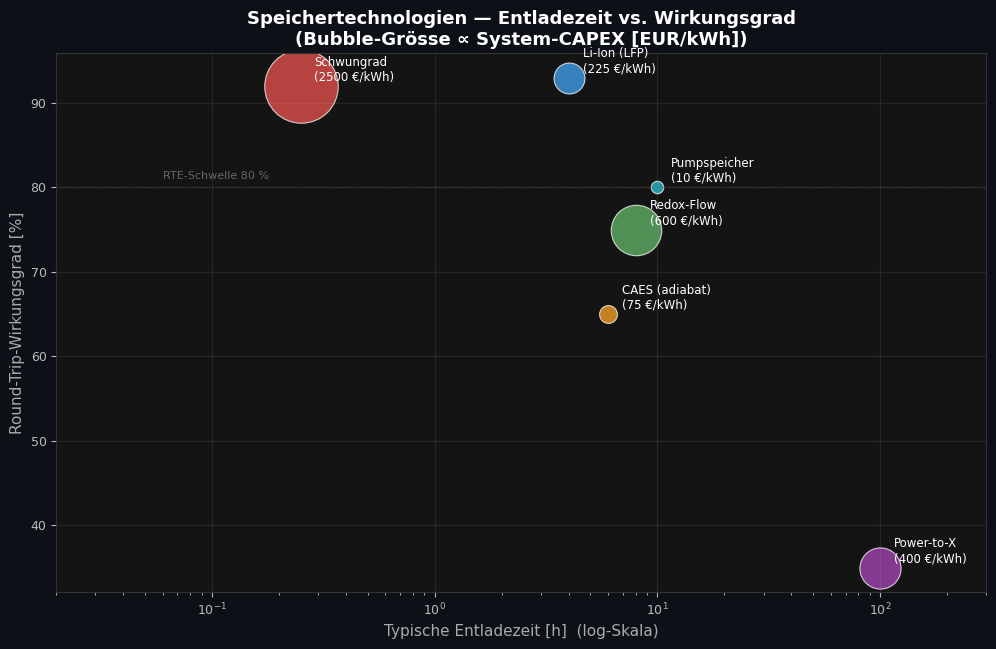

Gespeichert: ../output\charts\realistisch\kuer_k08_positionierung.png


In [7]:
# ── Bubble-Chart: Speichertechnologien ───────────────────────────────────────
# x = typische Entladezeit [h], y = RTE [%], Bubble-Grösse ~ CAPEX EUR/kWh
names    = ['Li-Ion (LFP)', 'Redox-Flow',  'Pumpspeicher', 'CAES (adiabat)', 'Power-to-X', 'Schwungrad']
dh_typ   = [4,             8,             10,              6,                100,           0.25]
rte      = [93,            75,            80,              65,                35,            92]
capex_n  = [225,           600,           10,              75,               400,           2500]  # EUR/kWh
colors_b = [C_PRIV,C_LOAD,C_CYAN,C_PRICE,C_DISPATCH,C_UTIL]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_DARK); ax.set_facecolor(BG_PANEL)
ax.tick_params(colors=C_TICK)
for sp in ax.spines.values(): sp.set_edgecolor(C_SPINE)

for name, dh, r, cx, col in zip(names, dh_typ, rte, capex_n, colors_b):
    size = max(80, min(2800, cx * 2.2))
    ax.scatter(dh, r, s=size, color=col, alpha=0.75, edgecolors='white', lw=LW_DUENN)
    ax.annotate(f'{name}\n({cx} \u20ac/kWh)', (dh, r),
                textcoords='offset points', xytext=(10, 4),
                color='white', fontsize=8.5)

ax.axhline(80, color='#555', lw=LW_DUENN, ls=':', alpha=0.7)
ax.text(0.06, 81, 'RTE-Schwelle 80 %', color='#666', fontsize=FS_LEGENDE)
ax.set_xscale('log')
ax.set_xlabel('Typische Entladezeit [h]  (log-Skala)', color=C_ACHSE, fontsize=11)
ax.set_ylabel('Round-Trip-Wirkungsgrad [%]', color=C_ACHSE, fontsize=11)
ax.set_title('Speichertechnologien — Entladezeit vs. Wirkungsgrad\n(Bubble-Grösse \u221d System-CAPEX [EUR/kWh])',
             color='white', fontweight='bold')
ax.grid(True, alpha=ALPHA_FLAECHE)
ax.set_xlim(0.02, 300)

p = os.path.join(CHARTS_DIR, 'kuer_k08_positionierung.png')
plt.savefig(p, dpi=DPI, bbox_inches='tight', facecolor=BG_DARK)
plt.show(); plt.close()
print(f"Gespeichert: {p}")


**Lesehilfe** (log-Skala X-Achse):
- **Oben Mitte/Rechts** — Langer Speicher + hoher Wirkungsgrad: [Li-Ion](../organisation/O_02_Glossar.ipynb#g-li-ion) (4h Utility-Standard) und Pumpspeicher — beide kommerziell etabliert
- **Oben Links** — Sehr kurze Entladezeit + hoher Wirkungsgrad: Schwungrad-Farmen (FCR, 15 min) — Nische Frequenzregelung
- **Mitte** — Mittlere Entladezeit, mittlerer Wirkungsgrad: [Redox-Flow](../organisation/O_02_Glossar.ipynb#g-redox-flow) (8h) und [CAES](../organisation/O_02_Glossar.ipynb#g-caes) (6h) — Utility-Grossspeicher
- **Rechts Unten** — Sehr langer Speicher, niedriger Wirkungsgrad: [Power-to-X](../organisation/O_02_Glossar.ipynb#g-power-to-x) (Tage–saisonal) — Sektorkopplung, nicht für Arbitrage

> **Hinweis Li-Ion:** Der Datenpunkt zeigt 4h (NREL ATB Utility-Standard). Li-Ion deckt tatsächlich 1–10h ab — von Residential (1–2h) bis Utility Long-Duration (8–10h). Die Entladezeit ist konfigurierbar, nicht technologiebedingt fix.

> **Hinweis Schwungrad:** Einzeleinheiten laden in Sekunden, Farmen erreichen 15–60 min effektive Entladezeit. Kapazitäten bis 80 MWh möglich (Arrays).


---
## 3. Einordnung im CH-Kontext <a id='einordnung-im-ch-kontext_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

| Technologie | Rol im CH-Energiesystem | Arbitrage-Eignung |
|---|---|---|
| **Pumpspeicher** | Hauptspeicher für saisonalen Ausgleich, Regelenergie | Gut (Grossskala) |
| **Li-Ion (LFP)** | Dezentral, schnell reagierend, modular | Sehr gut (alle Segmente) |
| **Redox-Flow** | Utility-Grossspeicher, langer Zyklushorizont | Gut (> 10 MWh) |
| **CAES** | Derzeit nicht relevant in CH (Geologie) | Bedingt |
| **Power-to-X** | Saisonaler Speicher, Sektorkopplung Strom/Gas/Wärme | Nicht für Arbitrage |
| **Schwungrad** | Netzregelung (FCR), USV — kein Energiespeicher im eigentlichen Sinn | Nein |

**Fazit für das Projekt:**  
[Grid-Arbitrage](../organisation/O_02_Glossar.ipynb#g-grid-arbitrage) mit Batterien und Pumpspeichern sind **komplementär** —
nicht kompetitiv. Batterien agieren im Tages- und Wochenspeicher-Bereich,
Pumpspeicher sichern den saisonalen Ausgleich und die Frequenzstabilität.
[Power-to-X](../organisation/O_02_Glossar.ipynb#g-power-to-x) schliesst die Lücke für mehrmonatige Speicherung.


---

---
## Fazit <a id='fazit_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

**Batteriespeicher und Pumpspeicher sind komplementär** — kein Wettbewerb.

| Dimension | Li-Ion Batterie | Pumpspeicher (CH) |
|-----------|----------------|-------------------|
| **Zeithorizont** | Stunden bis Tage | Tage bis saisonal |
| **Reaktionszeit** | Millisekunden | <30s (Spin) bis 5–15 min (Mode-Switch) |
| **Standort** | Dezentral, überall | Geographisch gebunden (Alpen) |
| **Arbitrage** | Täglich (Intraday) | Saisonal (Sommer pumpen, Winter erzeugen) |
| **CAPEX** | Sinkend (~−10%/J) | Stabil hoch (Infrastruktur) |
| **CH-Relevanz** | Wächst | Bereits ~9.5 GW installiert |

**Für Grid-Arbitrage im Schweizer Kontext:**
- **Privat/Gewerbe/Industrie:** Li-Ion (LFP) dominiert — Module, Kosten, Sicherheit
- **Utility ≥ 10 MWh:** Redox-Flow als strategische Alternative (> 20'000 Zyklen, kein Brandrisiko)
- **Saisonaler Ausgleich:** Bleibt Domäne der Pumpspeicher — keine realistische Batterie-Alternative bei diesen Zeitskalen und Volumina

→ Detaillierter Technologie- und Kostenvergleich: [K_07 – Technologievergleich](K_07_Technologievergleich.ipynb)


---
## Abschluss <a id='abschluss_K_08'></a>

[↑ Inhaltsverzeichnis](#toc_K_08)

Erzeugte Charts (Steckbriefe-Grid, Positionierungs-Scatter, CH-Einordnung)
auf Existenz prüfen — Referenzen in K_00 und K_07.

**🔎 Quellcode der importierten lib-Funktion**

Die Funktion `final_check` wird aus `lib/io_ops.py` importiert und
in der folgenden Zelle verwendet. Aufklappbar ist der Quellcode einsehbar


In [8]:
show_source(final_check)

<details>
<summary>🔎 Quellcode: <code>final_check</code> (aus <code>lib/io_ops.py</code>)</summary>

```python
def final_check(nb_label, files=None, *, weiter_msg=None, fehler_msg=None,
                extras=None, show_dataindex=False,
                dataindex_path='../sync/dataindex.csv', width=60):
    """Standardisierte End-of-Notebook-Kontrolle für Pflicht- und Kür-NBs.

    Prüft Existenz und Mindestgrösse der angegebenen Output-Dateien,
    gibt formatiertes Resultat aus und liefert ``all_ok`` als Bool zurück.

    Parameter
    ---------
    nb_label : str
        Label des Notebooks im Output-Header, z.B. ``"NB01"``, ``"K_03"``.
    files : list of tuple, optional
        Zu prüfende Dateien als ``(path, label, min_bytes)``-Tuples.

        * ``min_bytes = 0`` → nur Existenz prüfen, Grösse nicht ausgeben
          (z.B. für PNG-Charts).
        * ``min_bytes > 0`` → zusätzlich Grösse prüfen und in KB/MB ausgeben
          (z.B. für CSV-Dateien).

        Bei ``files=None`` oder ``files=[]`` wird kein Check ausgeführt;
        die Funktion dient dann als reiner Status-Print (für Report-NBs
        ohne eigene Outputs wie K_00).
    weiter_msg : str, optional
        Nachricht für den Erfolgsfall, z.B. ``"NB02 Daten Bereinigung"``.
        Default: ``"nächstes Notebook"``.
    fehler_msg : str, optional
        Nachricht für den Fehlerfall (Kurzform, ohne "Fehler beheben vor").
        Default: identisch mit ``weiter_msg``.
    extras : list of str, optional
        Zusätzliche Print-Zeilen zwischen Datei-Check und Weiter-/Fehler-Hinweis.
        Sinnvoll für Kür-Hinweise oder Kontext.
    show_dataindex : bool, default False
        Wenn True, wird der aktive Auszug aus ``../sync/dataindex.csv`` ausgegeben.
        Typisch für NB01.
    dataindex_path : str, default '../sync/dataindex.csv'
        Pfad zur dataindex.csv (für ``show_dataindex=True``).
    width : int, default 60
        Breite der Trennlinie aus ``=``-Zeichen.

    Return
    ------
    bool
        ``True`` wenn alle Files existieren und Mindestgrösse erfüllen,
        ``False`` sonst. Bei ``files=None``/leer immer ``True``.
    """
    print(f'{nb_label} – Abschlusskontrolle')
    print('=' * width)

    all_ok = True

    if files:
        for path, label, min_bytes in files:
            exists = os.path.exists(path)
            size = os.path.getsize(path) if exists else 0
            ok = exists and size >= min_bytes

            if min_bytes > 0:
                size_str = _format_size(size) if exists else '   FEHLT'
                print(f'  {"✅" if ok else "❌"}  {label:<45} {size_str}')
            else:
                print(f'  {"✅" if ok else "❌"}  {label}')

            if not ok:
                all_ok = False

    if extras:
        if files:
            print()
        for line in extras:
            print(line)

    if show_dataindex and os.path.exists(dataindex_path):
        import pandas as pd
        df_idx = pd.read_csv(dataindex_path)
        active = df_idx[df_idx['status'] == 'active']
        print(f'\ndataindex.csv: {len(df_idx)} Einträge total, {len(active)} active')
        print(active[['filename', 'data_type', 'rows', 'size_kb', 'timestamp']]
              .to_string(index=False))

    print()
    weiter = weiter_msg or 'nächstes Notebook'
    fehler = fehler_msg or weiter
    if all_ok:
        print(f'→ Weiter mit {weiter}.')
    else:
        print(f'→ Fehler beheben vor {fehler}.')

    return all_ok
```

</details>


---

In [9]:
# ── Abschlusskontrolle K_08 ─────────────────────────────────────────────────
final_check(
    'K_08',
    files=[
        (os.path.join(CHARTS_DIR, 'kuer_k08_positionierung.png'), 'Speichertechnologien-Bubble-Chart', 50_000),
    ],
    weiter_msg='K_00 (Business Strategy) oder zurück zu Pflicht-NBs',
)


K_08 – Abschlusskontrolle
  ✅  Speichertechnologien-Bubble-Chart                91.4 KB

→ Weiter mit K_00 (Business Strategy) oder zurück zu Pflicht-NBs.


True

| [← K_07 – Technologievergleich](K_07_Technologievergleich.ipynb) | [↑ Übersicht](../organisation/O_01_Project_Overview.ipynb) | [K_09 – Eigenverbrauchsoptimierung →](K_09_Eigenverbrauch.ipynb) |
|:---|:---:|---:|